# 빈도수 기반 텍스트 분석 : 다음 영화 리뷰

1. 데이터 준비 : 로딩, 피룡한 데이터 추출
2. 데이터 전처리 : 분석 대상 단어 집합
3. 데이터 분석 : 빈도수
4. 시각화 : 수평 막대 그래프, 워드클라우드

### 1. 데이터 준비

In [1]:
import pandas as pd
datafile = './data/daum_movie_review.csv'
data_df = pd.read_csv(datafile)
data_df.head()

,review,rating,date,title
0,돈 들인건 티가 나지만 보는 내내 하품만,1,2018.10.29,인피니티 워
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.,10,2018.10.26,인피니티 워
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...,8,2018.10.24,인피니티 워
3,이 정도면 볼만하다고 할 수 있음!,8,2018.10.22,인피니티 워
4,재미있다,10,2018.10.20,인피니티 워


In [2]:
reviews = list(data_df.review)
len(reviews), reviews[:5]

(14725,
 ['돈 들인건 티가 나지만 보는 내내 하품만',
  '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
  '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
  '이 정도면 볼만하다고 할 수 있음!',
  '재미있다'])

### 2. 데이터 전처리 -> 단어 집합

In [3]:
from konlpy.tag import Okt
okt = Okt()

# 리뷰에서 명사만 뽑아서 리스트로 만들기
all_nouns = []
for review in reviews:
    if isinstance(review, str):
        nouns = okt.nouns(review)
        # 한 글자짜리 단어(나, 는, 것 등)는 의미가 없으니 두 글자 이상만 저장
        all_nouns.extend([n for n in nouns if len(n) > 1])

print(all_nouns[:10]) # 결과 확인

['내내', '하품', '몰입', '생각', '전투', '참여', '이남', '이전', '작품', '스케일']


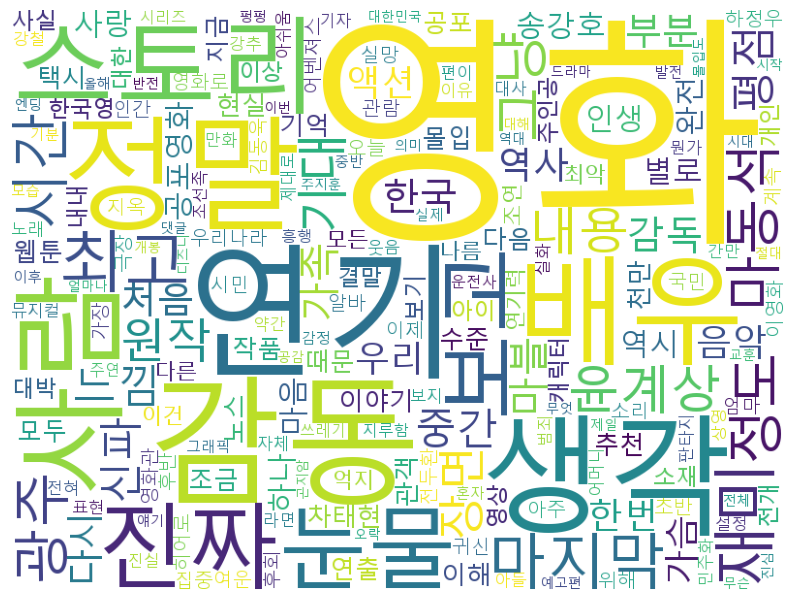

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 단어 개수 세기
c = Counter(all_nouns)

# 워드클라우드 그리기
wc = WordCloud(font_path='malgun', background_color='white', width=800, height=600)
cloud = wc.generate_from_frequencies(c)

plt.figure(figsize=(10, 8))
plt.imshow(cloud)
plt.axis('off')
plt.show()

3. 데이터 분석 (빈도수 계산)

In [7]:
from collections import Counter

# 단어 빈도수 계산 (이전 단계에서 만든 변수 이름 'all_nouns' 사용)
word_counts = Counter(all_nouns)

# 가장 많이 등장한 상위 20개 단어 확인
top_20_words = word_counts.most_common(20)
print(top_20_words)

[('영화', 6691), ('연기', 1293), ('감동', 1223), ('생각', 1027), ('정말', 948), ('배우', 847), ('사람', 819), ('스토리', 815), ('진짜', 781), ('눈물', 737), ('보고', 702), ('최고', 682), ('재미', 641), ('마지막', 612), ('시간', 596), ('마동석', 556), ('그냥', 533), ('정도', 531), ('광주', 530), ('윤계상', 517)]


4. 시각화 - (1) 수평 막대 그래프

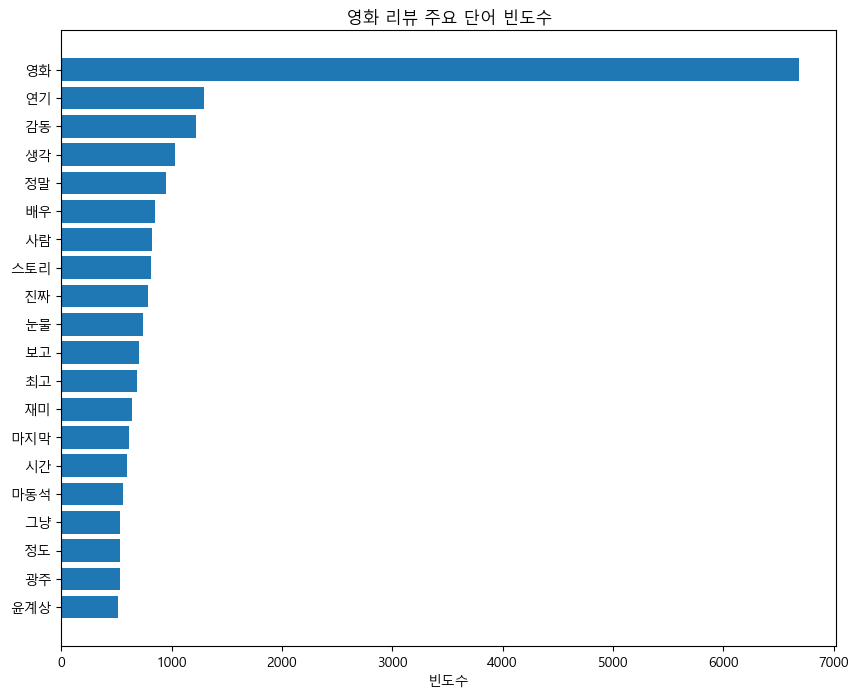

In [8]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 준비
words, counts = zip(*top_20_words)

plt.figure(figsize=(10, 8))
plt.barh(words, counts) # 수평 막대 그래프
plt.gca().invert_yaxis() # 빈도수 높은 순서대로 위로 오게 조정
plt.title('영화 리뷰 주요 단어 빈도수')
plt.xlabel('빈도수')
plt.show()

(2) 워드클라우드 (WordCloud)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. 'review_words' 대신 'all_nouns'를 사용하여 공백으로 합쳐줍니다.
cloud_text = " ".join(all_nouns)

# 2. 워드클라우드 생성
wc = WordCloud(
    font_path='malgun', # Windows의 경우 'malgun' 혹은 폰트 전체 경로
    background_color='white',
    width=800,
    height=600
).generate(cloud_text)

# 3. 화면 출력
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off') # 축 숨기기
plt.show()

NameError: name 'review_words' is not defined